# 01 · Preparación de datos — Tickets DANA

**Fase 3 de CRISP-DM (Data Preparation).** Este notebook toma los tickets crudos
(`data/raw/dana/dana-tickets.xlsx`) y produce el dataset **limpio y deduplicado** en
`data/processed/`. Cada paso usa funciones del paquete `epsel.cleaning` (puras y testeables);
aquí solo las orquestamos y vemos el antes/después.

**Pasos:** tipos → selección de columnas → separar PII → normalizar categóricas →
variables derivadas → normalizar solución → deduplicar eventos → guardar.

> Corre las celdas en orden (Shift+Enter). Puedes ajustar parámetros como `window_days`.

In [1]:
# Setup: recarga automática del paquete epsel al editarlo
%load_ext autoreload
%autoreload 2

import pandas as pd
pd.set_option("display.max_columns", None)

from epsel import config, cleaning as cl
from epsel.io import load_tickets
config.ensure_dirs()

## 1. Cargar datos crudos
`load_tickets()` ya corrige los tipos de fecha (FECHA SOLUCION venía como serial de Excel) y añade `DURACION_DIAS`.

In [2]:
df = load_tickets()
print("Dimensiones:", df.shape)
df.head(3)

Dimensiones: (15141, 24)


,TICKET,ALCANCE,MEDIO RECEPCIÓN,FECHA REGISTRO,USUARIO REGISTRA,DISTRITO,SUMINISTRO,DIRECCION,PERSONA,DNI,CELULAR,TELEFONO FIJO,CORREO ELECTRÓNICO,PARENTESCO,GRUPO,TIPO GRUPO,CATEGORÍA,TIPO DE ATENCION,DETALLE DEL TICKET,ESTADO DEL TICKET,USUARIO SOLUCIONA,DETALLE DE SOLUCIÓN,FECHA SOLUCION,DURACION_DIAS
0,10414,general,presencial,2025-01-01 08:07:39,PEDRO.GARCIA,CHICLAYO,1111313.0,SANTA VICTORIA LOS FAIQUES NRO. 132,CARRASCO ESPINAR TOMAS,16451290,947098001,NaN,landaalicia26@gmail.com,TITULAR,OPERACIONES,DESAGUE,RECLAMO OPERACIONAL,ATORO EN COLECTORES Y/O DESBORDE ALCANTARILLADO,USUARIO ESTA COMUNICANDO ATORO EN CALLE LOS...,Finalizado,YOSBAR.LOPEZ,NaN,2025-01-06 19:35:19.000031818,5.477546
1,10415,general,telefono,2025-01-01 09:16:01,PEDRO.GARCIA,CHICLAYO,1215318.0,BARRIO ZAMORA URETA M. NRO. 180,CARNAQUE CARRASCO ALFREDO,16802656,996255524,NaN,esantistebannique@gmail.com,TITULAR,OPERACIONES,DESAGUE,RECLAMO OPERACIONAL,ATORO EN COLECTORES Y/O DESBORDE ALCANTARILLADO,USUARIO ESTA COMUNICANDO ATORO EN CALLE E. UR...,Finalizado,YOSBAR.LOPEZ,atendido,2025-01-31 15:07:29.999971295,30.244086
2,10416,general,telefono,2025-01-01 09:31:04,PEDRO.GARCIA,CHICLAYO,1489523.0,9 DE OCTUBRE LOS MITOS NRO. 361,CALDERON DE DIAZ MARIA,40396190,970598768,NaN,esantistebannique@gmail.com,TITULAR,OPERACIONES,DESAGUE,RECLAMO OPERACIONAL,ATORO EN COLECTORES Y/O DESBORDE ALCANTARILLADO,USUARIO ESTA COMUNICANDO ATORO EN CALLE LOS...,Finalizado,YOSBAR.LOPEZ,NaN,2025-01-12 23:42:10.000022702,11.591042


## 2. Selección de columnas — quitar constantes
Las columnas `GRUPO`, `CATEGORÍA` y `ESTADO DEL TICKET` tienen un solo valor → no aportan.

In [3]:
print("Columnas constantes a eliminar:", cl.COLUMNAS_CONSTANTES)
df = cl.drop_constant_columns(df)
print("Dimensiones tras quitar constantes:", df.shape)

Columnas constantes a eliminar: ['GRUPO', 'CATEGORÍA', 'ESTADO DEL TICKET']
Dimensiones tras quitar constantes: (15141, 21)


## 3. Separar datos personales (PII)
Por privacidad separamos PERSONA, DNI, CELULAR, etc. en una tabla aparte. El dataset
analítico conserva `PERSONA_HASH` (DNI hasheado) para medir recurrencia por persona
**sin exponer el dato**. La tabla PII no se persiste en este flujo.

In [4]:
df, df_pii = cl.split_pii(df)
print("Analitico:", df.shape, "| PII (no se guarda):", df_pii.shape)
print("Columnas PII separadas:", [c for c in df_pii.columns if c != 'TICKET'])
df[["TICKET", "PERSONA_HASH"]].head(3)

Analitico: (15141, 16) | PII (no se guarda): (15141, 7)
Columnas PII separadas: ['PERSONA', 'DNI', 'CELULAR', 'TELEFONO FIJO', 'CORREO ELECTRÓNICO', 'PARENTESCO']


,TICKET,PERSONA_HASH
0,10414,e4f6165cb7ff
1,10415,4960e5fa816b
2,10416,4d1429f2a231


## 4. Normalizar categóricas
Mayúsculas, sin acentos ni puntuación, para evitar duplicados por grafía (`Vía Pública` vs `VIA PUBLICA`).

In [5]:
df = cl.normalize_categories(df)
df["TIPO DE ATENCION"].value_counts().head(8)

TIPO DE ATENCION
ATORO EN COLECTORES Y/O DESBORDE ALCANTARILLADO          6459
FUGA DE AGUA EN CONEX DOMICILIARIA (FUGA ACOMETIDA)      2405
OTROS - AGUA ESPECIFICAR                                 1956
ATORO EN REDES PRIMARIA                                  1585
FALTA DE AGUA                                             888
COLOCACION TAPA DE BUZON                                  828
FUGAS DE AGUA EN RED DE AGUA (INC REPARA CORPORACION)     387
OTROS - DESAGUE                                           376
Name: count, dtype: int64

## 5. Variables derivadas
`CATEGORIA_INCIDENCIA` (macro-tipo: ATORO/FUGA/...), `UBICABLE`, `TIENE_SUMINISTRO`, `ANIO_MES`.

In [6]:
df = cl.add_derived(df)
print(df["CATEGORIA_INCIDENCIA"].value_counts())
print("\nUbicables: {:.1f}%  |  Con suministro: {:.1f}%".format(
    df["UBICABLE"].mean()*100, df["TIENE_SUMINISTRO"].mean()*100))

CATEGORIA_INCIDENCIA
ATORO           8100
FUGA            2792
OTROS           2416
FALTA_AGUA       888
TAPA_BUZON       839
BAJA_PRESION      67
INSPECCION        14
CALIDAD           14
ROTURA             6
REPARACION         5
Name: count, dtype: int64

Ubicables: 73.7%  |  Con suministro: 73.7%


## 6. Normalizar el texto de solución
`DETALLE DE SOLUCIÓN` es texto libre con muchos typos (`ATENDIDA`, `ATENIDIDO`, `AENDIDA`...).
Lo colapsamos en `ESTADO_SOLUCION` canónico.

In [7]:
df = cl.normalize_solucion(df)
df[["DETALLE DE SOLUCIÓN", "ESTADO_SOLUCION"]].value_counts().head(10)

DETALLE DE SOLUCIÓN  ESTADO_SOLUCION
ATENDIDA             ATENDIDA           4396
ATENDIDA.            ATENDIDA           3847
FINALIZO             FINALIZADO          459
ATENDIDO             ATENDIDA            190
SE ATENDIÓ           ATENDIDA            180
ATENIDIDO            ATENDIDA            105
atendido             ATENDIDA             61
SE ATENDIO           ATENDIDA             54
FINALIZAR            FINALIZADO           53
SE SOLUCIONO         SOLUCIONADO          38
Name: count, dtype: int64

## 7. Geocodificación de direcciones (dirección → latitud/longitud)
El dataset **no trae coordenadas**. Aquí las **derivamos de `DIRECCION`**. Es el enabler que
desbloquea el mapa de calor, el clustering y la causa raíz aplicada a un reclamo.

Soportamos dos proveedores (`provider`):

| | **Google** (recomendado) | **Nominatim** (OpenStreetMap) |
|---|---|---|
| Precisión en PE | Alta (numeración + urbanizaciones) | Baja (cae a centroide de barrio) |
| API key | Sí, con facturación | No |
| Costo | ~$200/mes gratis (≈40.000 geocodif.) → nuestras ~8.000 **gratis** | Gratis |
| Velocidad | Alta | 1 consulta/seg (las ~8.000 ≈ 2 h) |

**Configurar Google (una vez):** crea un proyecto en
[Google Cloud Console](https://console.cloud.google.com), habilita **"Geocoding API"** y la
facturación, genera una **API key** y expórtala antes de abrir el notebook:

```bash
# PowerShell:  $env:GOOGLE_MAPS_API_KEY = "TU_KEY"
# bash:        export GOOGLE_MAPS_API_KEY="TU_KEY"
```

**Cuidados:** solo se consultan direcciones **únicas** y se **cachean** en
`data/interim/geocode_cache.csv` (re-ejecutar no repite llamadas). `MAX_DIRECCIONES` arranca
pequeño para probar; ponlo en `None` para procesar todas. Se valida que la coordenada caiga
en **Lambayeque** (`COORD_VALIDA`) y se etiqueta la `PRECISION_COORD`.

In [8]:
from epsel import geocoding as geo

PROVIDER = "google"      # "google" (preciso, requiere API key) | "nominatim" (gratis)
MAX_DIRECCIONES = 30     # nuevas a geocodificar esta corrida; pon None para TODAS

try:
    cache = geo.geocode_addresses(
        df["DIRECCION"],
        cache_path=config.INTERIM / "geocode_cache.csv",
        provider=PROVIDER,
        max_n=MAX_DIRECCIONES,
        # api_key="TU_KEY",   # o exporta GOOGLE_MAPS_API_KEY (recomendado)
    )
except ValueError as e:
    print("⚠️", e)
    cache = {}

⚠️ Falta la API key de Google. Crea una en https://console.cloud.google.com (habilita 'Geocoding API' y facturación) y pásala como api_key=... o expórtala en la variable de entorno GOOGLE_MAPS_API_KEY. Alternativa sin key: provider='nominatim'.


In [9]:
df = geo.attach_coords(df, cache)
con_dir = int(df["DIRECCION"].notna().sum())
ok = int(df["COORD_VALIDA"].sum())
print(f"Tickets con coordenada válida (dentro de Lambayeque): {ok:,} "
      f"de {con_dir:,} con dirección ({ok/con_dir*100:.1f}%)")
if ok:
    print("\nPrecisión de las coordenadas:")
    print(df.loc[df["COORD_VALIDA"], "PRECISION_COORD"].value_counts().to_string())
df.loc[df["COORD_VALIDA"], ["DIRECCION", "LATITUD", "LONGITUD", "PRECISION_COORD"]].head(5)

Tickets con coordenada válida (dentro de Lambayeque): 0 de 11,159 con dirección (0.0%)


,DIRECCION,LATITUD,LONGITUD,PRECISION_COORD


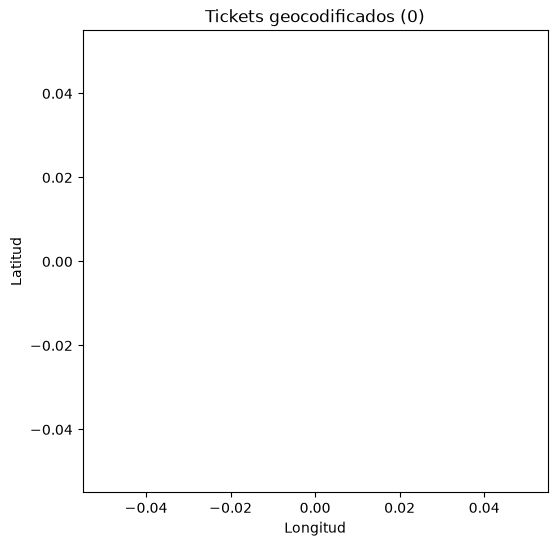

In [10]:
# Vista rápida de los puntos geocodificados
import matplotlib.pyplot as plt
pts = df[df["COORD_VALIDA"]]
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pts["LONGITUD"], pts["LATITUD"], s=10, alpha=0.5, color="#1F4E78")
ax.set_title(f"Tickets geocodificados ({len(pts)})")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
plt.show()

## 8. Deduplicación de eventos
Varias órdenes del **mismo suministro y servicio** registradas dentro de una ventana
temporal corta = un **mismo evento** (problema "una llamada = una orden").

⚠️ Esto NO es lo mismo que la *recurrencia* (un punto que falla repetidamente a lo largo
del año): eso se mide con la ventana larga y es una señal de criticidad, no un duplicado.

Ajusta `window_days` para ver el efecto (7 días = conservador).

In [11]:
window_days = 7
df = cl.assign_event_ids(df, window_days=window_days)
n_dup = (df["N_RECLAMOS_EVENTO"] > 1).sum()
print(f"Ventana: {window_days} días")
print(f"Tickets: {len(df):,}")
print(f"Eventos únicos: {df['EVENTO_ID'].nunique():,}")
print(f"Reducción por deduplicación: {(1 - df['EVENTO_ID'].nunique()/len(df))*100:.1f}%")
print(f"Tickets que son parte de un evento multi-reclamo: {n_dup:,}")

Ventana: 7 días
Tickets: 15,141
Eventos únicos: 14,555
Reducción por deduplicación: 3.9%
Tickets que son parte de un evento multi-reclamo: 1,120


In [12]:
# Sensibilidad de la deduplicación a la ventana temporal
for w in [1, 3, 7, 15, 30]:
    tmp = cl.assign_event_ids(df, window_days=w)
    red = (1 - tmp["EVENTO_ID"].nunique()/len(tmp))*100
    print(f"  ventana {w:>2} días -> {tmp['EVENTO_ID'].nunique():,} eventos  (reducción {red:.1f}%)")

  ventana  1 días -> 14,927 eventos  (reducción 1.4%)


  ventana  3 días -> 14,793 eventos  (reducción 2.3%)
  ventana  7 días -> 14,555 eventos  (reducción 3.9%)
  ventana 15 días -> 14,270 eventos  (reducción 5.8%)
  ventana 30 días -> 13,850 eventos  (reducción 8.5%)


## 9. Tabla de eventos (incidencias únicas)
Un registro por evento, con `N_RECLAMOS` (cuántas órdenes lo generaron) y las coordenadas — insumo para el mapa de calor y el scoring de criticidad.

In [13]:
eventos = cl.collapse_to_events(df)
print("Eventos:", len(eventos))
eventos.head(8)

Eventos: 14555


,EVENTO_ID,TICKET,N_RECLAMOS,SUMINISTRO,DIRECCION,DISTRITO,TIPO_GRUPO,CATEGORIA_INCIDENCIA,FECHA_PRIMER_RECLAMO,FECHA_ULTIMO_RECLAMO,DURACION_MEDIA_DIAS,LATITUD,LONGITUD,COORD_VALIDA
8413,6833976|AGUA|1,11970,6,6833976.0,SANTA ROSA PNP SIN NOMBRE MNZ. 19 LT. 16 NRO.,CHICLAYO,AGUA,FALTA_AGUA,2025-02-03 12:10:02,2025-02-18 07:31:15,24.460581,None,None,False
2328,1210993|DESAGUE|2,20456,5,1210993.0,SAN MARTIN LA UNION NRO. 156,CHICLAYO,DESAGUE,OTROS,2025-08-15 10:56:59,2025-09-02 17:33:58,12.524336,None,None,False
2975,1270860|DESAGUE|1,10723,4,1270860.0,SAN ANTONIO SAN CRISTOBAL - P.J.SAN ANTONIO N...,CHICLAYO,DESAGUE,ATORO,2025-01-08 13:55:24,2025-01-22 08:00:45,11.012274,None,None,False
6548,1641347|DESAGUE|1,11630,4,1641347.0,HIPOLITO UNANUE HIPOLITO UNANUE MNZ. A LT. -07...,CHICLAYO,DESAGUE,ATORO,2025-01-27 10:18:50,2025-02-06 11:25:07,11.683845,None,None,False
5269,1515811|DESAGUE|1,23401,4,1515811.0,SANTA ROSA LIMA NRO. 160,CHICLAYO,DESAGUE,ATORO,2025-11-04 10:34:21,2025-11-24 06:58:43,16.901201,None,None,False
5301,1518983|AGUA|2,24837,3,1518983.0,12 DE OCTUBRE SALAS NRO. 235,CHICLAYO,AGUA,FALTA_AGUA,2025-12-12 16:20:55,2025-12-12 16:21:04,5.667782,None,None,False
1941,1182578|DESAGUE|1,23846,3,1182578.0,LA VICTORIA PARAMONGA NRO. 471,CHICLAYO,DESAGUE,ATORO,2025-11-16 12:09:30,2025-11-19 15:53:09,46.213194,None,None,False
1737,1162176|DESAGUE|2,13749,3,1162176.0,V.R.H.DE LA TORRE-LA VICT. ZONAL MNZ. B LT. 20...,CHICLAYO,DESAGUE,ATORO,2025-03-10 09:30:46,2025-03-18 07:01:59,11.658769,None,None,False


## 10. Guardar resultados en `data/processed/`
Formato Parquet (eficiente, conserva tipos) + CSV para inspección manual. Ya incluye `LATITUD`/`LONGITUD`.

In [14]:
# Algunas columnas 'object' traen tipos mezclados (texto + fechas sueltas de Excel) y
# Parquet las rechaza; las pasamos a 'string'. Seleccionamos solo las verdaderamente
# 'object' por igualdad de dtype (evita el Pandas4Warning de select_dtypes en pandas 3).
def _a_string(d):
    d = d.copy()
    for c in d.columns:
        if d[c].dtype == object:          # solo object real, no el nuevo dtype str
            d[c] = d[c].astype("string")
    return d

df = _a_string(df)
eventos = _a_string(eventos)

out_tickets = config.PROCESSED / "tickets_clean.parquet"
out_eventos = config.PROCESSED / "eventos.parquet"
df.to_parquet(out_tickets, index=False)
eventos.to_parquet(out_eventos, index=False)
eventos.to_csv(config.PROCESSED / "eventos.csv", index=False, encoding="utf-8-sig")
print("Guardado:")
print(" -", out_tickets.relative_to(config.ROOT))
print(" -", out_eventos.relative_to(config.ROOT))
print(" -", (config.PROCESSED / 'eventos.csv').relative_to(config.ROOT))

Guardado:
 - data\processed\tickets_clean.parquet
 - data\processed\eventos.parquet
 - data\processed\eventos.csv


## Resumen
- Se quitaron 3 columnas constantes y se separó la PII.
- Se normalizaron categóricas y el texto de solución; se derivó `CATEGORIA_INCIDENCIA`.
- Se asignó `EVENTO_ID` para deduplicar órdenes del mismo evento.
- Se geocodificó la dirección (`LATITUD`/`LONGITUD`) con caché — habilita el mapa.
- Salida lista en `data/processed/` para la fase de modelado.

**Notas:** la geocodificación por dirección es una **aproximación**; su precisión depende del
proveedor (Google ubica a nivel de predio; Nominatim suele caer al centroide del barrio). La
vía más precisa de todas sigue siendo la tabla `SUMINISTRO → geometría` del catastro comercial.
Para geocodificar las ~8.000 direcciones, correr el paso 7 con `MAX_DIRECCIONES = None`.